# HMM Regime Detection on the Latent Manifold
#### Motivation and fit
Your embedding organises months geometrically; an HMM adds temporal structure: persistent
hidden regimes with Markov switching. Fitting the HMM on the diffusion coordinates rather
than on 45 raw series is the manifold-aware twist: three coordinates, so a full-covariance Gaussian
HMM is estimable without regularisation heroics. The punchline: do data-driven regimes recover
NBER recessions, and do your geodesic paths cross regime boundaries where they should?


In [123]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.sparse.csgraph import shortest_path, connected_components
from scipy.spatial.distance import squareform, pdist, cdist
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import cohen_kappa_score
from scipy.signal import find_peaks
import matplotlib.dates as mdates
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm
import plot_style as ps

In [2]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q}

def graph_degree_density(Psi, h):
    Dsq = squareform(pdist(Psi)**2)
    rho = np.exp(-Dsq/h).sum(1)
    scale = rho.mean(); rho /= scale
    rho = np.maximum(rho, 1e-6)
    return rho, -np.log(rho), scale

def density_and_bandwidth(Psi, multiplier=0.1):
    N = Psi.shape[0]
    median_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
    h = multiplier * median_Dsq
    return h, median_Dsq, graph_degree_density(Psi, h)

In [3]:
K_GRAPH = 15
BETA = 1.5
N_DIFFUSION_COORDS = 4
EPS_DIFFUSION = 3
N_LINEAR_GRID = 40
M_LIFT = 22

df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
dates = df.index; variables = df.columns[:-1]
Z = df.to_numpy()[:, :-1]; N = Z.shape[0]

obs_df = pd.read_parquet("./datasets/transformed_observed_df.parquet").loc[dates]
Z_real = obs_df[variables].to_numpy()

endpoint_pairs = {"2006 benign -> 2008 GFC": ("2006-03-01", "2008-10-01"), "2019 benign -> 2020 COVID": ("2019-07-01", "2020-04-01"), 
                  "2019 benign -> 2021 Fiscal Tightening": ("2019-04-01", "2022-04-01"), "1977 benign -> 1982 Recession Trough": ("1977-01-01", "1982-07-01")}
pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

In [4]:
diff = diffusion_map(Z, EPS_DIFFUSION, k=N_DIFFUSION_COORDS)
Psi = diff["Psi"]

h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi)

A_dist = kneighbors_graph(Psi, n_neighbors=K_GRAPH, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

# Task IV.1 — Baseline Gaussian HMM on $\Psi$

#### Train / test split

In [5]:
split_idx = dates.get_loc("2007-01-01")
Psi_train = Psi[:split_idx]
Psi_test = Psi[split_idx:]


In [6]:
def best_hmm_model(Psi, K):
    best_score = -np.inf; best_model = None
    for i in range(20):
        model = hmm.GaussianHMM(n_components=K, covariance_type='full', n_iter=100, random_state=i)
        model.fit(Psi)
        if not model.monitor_.converged: continue
        score = model.score(Psi)
        if score > best_score:
            best_score = score; best_model = model

    if best_model is None:
        raise RuntimeError(f"No converged model found for K={K}")
    return best_model, best_score


def best_hmm_oos(Psi_train, Psi_test, K):
    best_score = -np.inf; best_model = None
    for i in range(20):
        model = hmm.GaussianHMM(n_components=K, covariance_type='full', n_iter=100, random_state=i)
        model.fit(Psi_train)
        if not model.monitor_.converged: continue
        score = model.score(Psi_train)
        if score > best_score:
            best_score = score; best_model = model 

    if best_model is None:
        raise RuntimeError(f"No converged model found for K={K}")
    return best_model.score(Psi_test)  

def hmm_parameter_count(n_components, n_features):
    K = n_components; d = n_features
    return (K-1) + K*(K-1) + K*d + K * d*(d+1) // 2

#### Testing the different models

In [7]:
rows = []; models = {}
T, d = Psi.shape

for K in [2, 3, 4, 5, 6, 7]:
    best_model_k, best_score_k = best_hmm_model(Psi, K)
    p = hmm_parameter_count(K, d)
    bic = p*np.log(T) - 2*best_score_k
    oos_score = best_hmm_oos(Psi_train, Psi_test, K)
    rows.append({"n_components": K, "BIC": bic, "OOS_log_liklihood": oos_score})
    models[K] = best_model_k
hmm_df = pd.DataFrame(rows)

Model is not converging.  Current: 2668.93720748483 is not greater than 2668.9474621084855. Delta is -0.010254623655328032
Model is not converging.  Current: 2737.0248872411444 is not greater than 2737.027583634008. Delta is -0.002696392863526853
Model is not converging.  Current: 2743.362771440055 is not greater than 2743.384978893754. Delta is -0.02220745369913857
Model is not converging.  Current: 3899.660148796614 is not greater than 3899.663062898561. Delta is -0.0029141019467715523
Model is not converging.  Current: 3782.420224453328 is not greater than 3782.42445979608. Delta is -0.004235342752053839
Model is not converging.  Current: 2793.8862813458863 is not greater than 2794.0032664002547. Delta is -0.11698505436834239
Model is not converging.  Current: 2791.865650188502 is not greater than 2791.8848163268503. Delta is -0.019166138348282402
Model is not converging.  Current: 2826.643111769693 is not greater than 2826.6600106553487. Delta is -0.016898885655791673
Model is not 

In [8]:
hmm_df

,n_components,BIC,OOS_log_liklihood
0,2,-6366.331473,709.547189
1,3,-6888.769086,816.474385
2,4,-7178.345334,885.243158
3,5,-7243.755812,908.469796
4,6,-7329.851664,906.030312
5,7,-7307.997052,893.124394


Looks like $K=6$ is the best choice


In [54]:
chosen_K = 6

### Transition matrix and stationary distribution
The stationary distribution $\pi$ satisfies $\pi A = \pi \iff A^\top \pi^\top = \pi^\top$, so $\pi$ is the eigenvector corresponding to the eigenvalue 1.

Stationary distribution: [0.14281102 0.22003857 0.11935415 0.23063981 0.07289541 0.21426104]
Number of observations in each state: {'state 0': 102, 'state 1': 178, 'state 2': 84, 'state 3': 179, 'state 4': 52, 'state 5': 148}


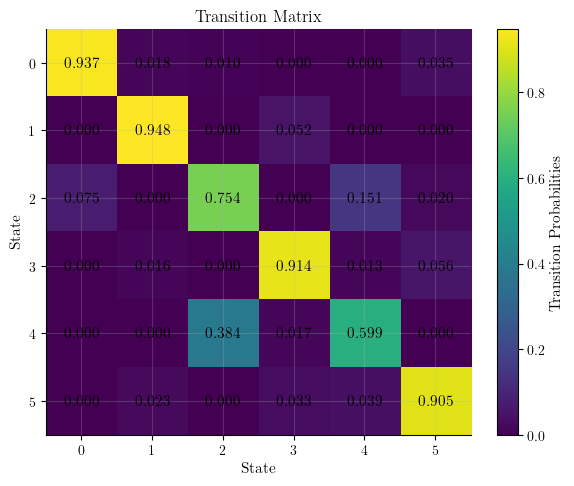

In [55]:
A = models[chosen_K].transmat_
K = A.shape[0]

eigvals, eigvecs = np.linalg.eig(A.T)
pi = np.real(eigvecs[:, np.argmin(np.abs(eigvals - 1))])
pi = pi / pi.sum()
print(f'Stationary distribution: {pi}')

states = models[chosen_K].predict(Psi)
print(f'Number of observations in each state: {({f"state {i}": np.sum(states==i) for i in range(chosen_K)})}')

fig, ax = plt.subplots(figsize=(6, 5)); im = ax.imshow(A, aspect="auto")
for i in range(K): 
    for j in range(K):
        ax.text(j, i, f"{A[i, j]:.3f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Transition Probabilities")
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_title("Transition Matrix")
ax.set_xlabel("State"); ax.set_ylabel("State")
plt.tight_layout(); plt.show()

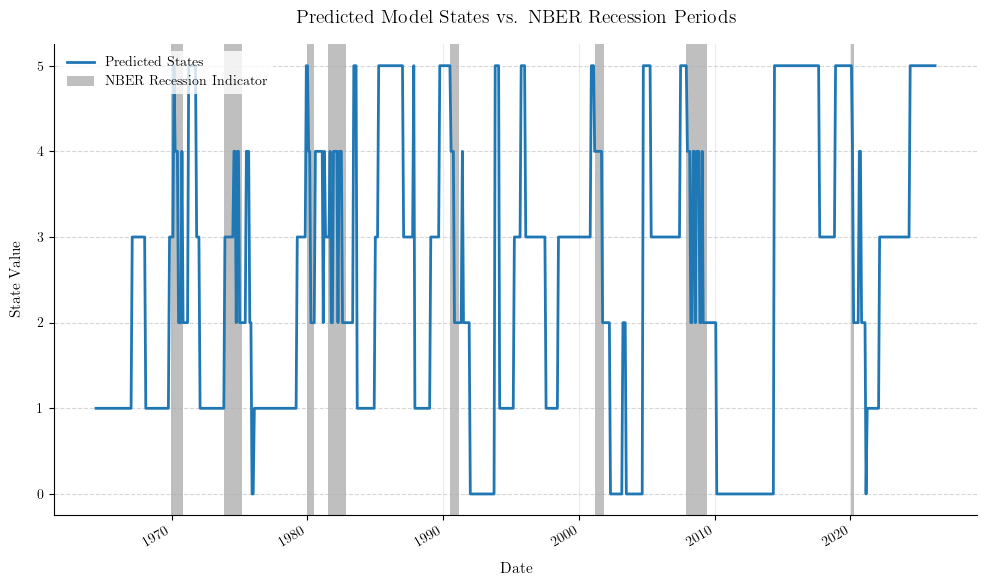

In [56]:
states = models[chosen_K].predict(Psi)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df.index, states, label="Predicted States", color="#1f77b4", linewidth=2)

y_min, y_max = ax.get_ylim()

ax.fill_between(df.index, y_min, y_max, where=(df["recession"].values == 1), color="gray",
                alpha=0.5, label="NBER Recession Indicator", edgecolor="none")

ax.set_ylim(y_min, y_max)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

ax.set_title("Predicted Model States vs. NBER Recession Periods", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, labelpad=10)
ax.set_ylabel("State Value", fontsize=11, labelpad=10)
ax.set_yticks(range(chosen_K))

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False) 
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()
plt.show()


### per-state means in macro language (transformed observations)



The transforms are {'UNRATE': $x$, 'FEDFUNDS': $\Delta x$, 'CPIAUCSL': $\Delta^2\log(x)$, 'S&P 500': $\Delta\log(x)$, 'HOUST': $\log(x)$}

,UNRATE,FEDFUNDS,CPIAUCSL,S&P 500,HOUST
state,,,,,
0,7.378431,-0.019118,0.000015,0.006458,6.967582
1,5.445506,0.121348,0.000067,0.003299,7.399149
2,7.871429,-0.374048,-0.000125,0.029861,7.004698
3,4.703911,0.092123,-0.000075,0.008260,7.321391
4,6.605769,-0.013846,-0.000080,-0.036595,7.068999
5,5.298986,-0.026081,0.000136,0.007612,7.245362


,UNRATE,FEDFUNDS,CPIAUCSL,S&P 500,HOUST
state,,,,,
0,0.919963,0.098892,0.250748,0.152632,-1.121081
1,-0.611543,0.893304,0.773914,0.006925,1.294628
2,1.310577,-1.908431,-1.146892,1.232078,-0.913325
3,-1.199127,0.728019,-0.640386,0.235724,0.859375
4,0.307763,0.128706,-0.696174,-1.833220,-0.553396
5,-0.727633,0.059510,1.458790,0.205861,0.433799


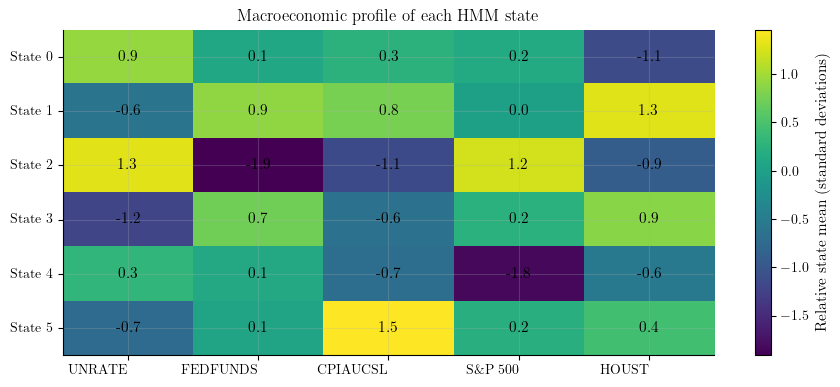

In [57]:
macro_with_states = obs_df.copy()
macro_with_states["state"] = models[chosen_K].predict(Psi)

state_means = macro_with_states.groupby("state")[["UNRATE", "FEDFUNDS", "CPIAUCSL", "S&P 500", "HOUST"]].mean()
display(state_means)

state_means_z = (state_means - state_means.mean(axis=0)) / state_means.std(axis=0)
display(state_means_z)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(state_means_z, aspect="auto")

ax.set_xticks(range(len(state_means_z.columns)))
ax.set_xticklabels(state_means_z.columns.str.replace("&", "\&"), ha="right")
ax.set_yticks(range(len(state_means_z.index)))
ax.set_yticklabels([f"State {i}" for i in state_means_z.index])

for i in range(state_means_z.shape[0]):
    for j in range(state_means_z.shape[1]):
        ax.text(
            j, i,
            f"{state_means_z.iloc[i, j]:.1f}",
            ha="center", va="center"
        )

fig.colorbar(im, ax=ax, label="Relative state mean (standard deviations)")
ax.set_title("Macroeconomic profile of each HMM state")
plt.tight_layout()
plt.show()

I am debating my choice of $K$. By the BIC and OOS log-liklihood tests, it seems as if $K=6$ is the optimal choice. However this means that the model is identifying 6 seperate economic states, which seems almost too good to be true with our small sample size. Maybe I am being pessimistic though. 

- State 0: high unemployment, roughly flat rates, slightly positive equity returns, low housing activity.
    - This looks like a weak or sluggish regime rather than an acute crisis.
- State 1: below-average unemployment, strongly rising interest rates, positive inflation acceleration, high housing activity.
    - This looks like an expansion with monetary tightening.
- State 2: very high unemployment, sharply falling interest rates, falling inflation momentum, strong positive equity returns, weak housing.
    - This could be an early recovery or policy-response state: bad real economy, aggressive easing, recovering markets.
- State 3: very low unemployment, rising rates, falling inflation momentum, positive equities, strong housing.
    - This looks like a strong mature expansion.
- State 4: moderately high unemployment, large negative equity returns, weak housing, slightly falling rates and inflation momentum.
    - This is the clearest crisis or financial-stress state.
- State 5: low unemployment, strongly positive inflation acceleration, positive equities, moderately strong housing.
    - This may be an inflationary expansion state.


The Viterbi path shows that the recession periods never occur in state 0 or 1, and during the recession periods the states bounce between 2 and 4, this would make sense given the above interpretations of the states as the US is trying to recover but the economy is still poor.

# Task IV.2 — Validation against NBER and against your density
### (i) NBER agreement

In [ ]:
results = []
for state in np.unique(states):
    state_indicator = (states == state).astype(int)
    kappa = cohen_kappa_score(df["recession"].values, state_indicator)
    results.append({"state": state, "cohens_kappa": kappa})

kappa_results = pd.DataFrame(results).sort_values("cohens_kappa", ascending=False)
print(kappa_results.to_string(index=False))

 state  cohens_kappa
     4      0.477203
     2      0.326801
     3     -0.082795
     5     -0.132629
     0     -0.150675
     1     -0.187952


This shows that there is a moderate agreement between the state 4 value and the NBER recession state. There is also a positive agreement with state 2 which is observed in the Viterbi path plot.

Evaluation Metric    | Value     
Accuracy             | 0.9071
Precision            | 0.7308
Recall               | 0.4086
Specificity          | 0.9785
F1-Score             | 0.5241
Balanced Accuracy    | 0.6935


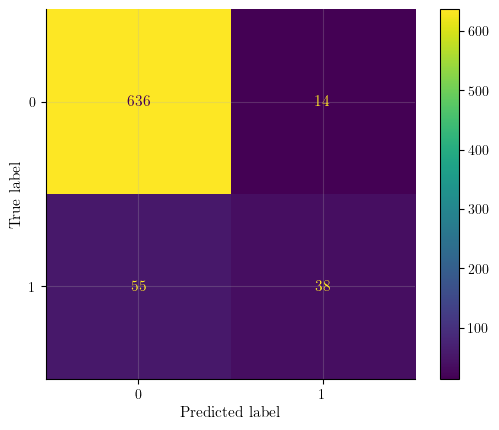

In [76]:
matrix = confusion_matrix(df["recession"].values, (states == 4).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=matrix)
disp.plot()

tn, fp, fn, tp = matrix.ravel()
accuracy = (tp + tn) / matrix.sum()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * precision * recall / (precision + recall)
balanced_accuracy = (recall + specificity) / 2

print("=" * 35)
print(f"{'Evaluation Metric':<20} | {'Value':<10}")
print("=" * 35)
print(f"{'Accuracy':<20} | {accuracy:.4f}")
print(f"{'Precision':<20} | {precision:.4f}")
print(f"{'Recall':<20} | {recall:.4f}")
print(f"{'Specificity':<20} | {specificity:.4f}")
print(f"{'F1-Score':<20} | {f1:.4f}")
print(f"{'Balanced Accuracy':<20} | {balanced_accuracy:.4f}")
print("=" * 35)

The recall score is very low, this state only catches around 40% of the actual recession states. Looking at the Viterbi plot, it does look like the recession points are mainly split between state 4 and state 2. I have tried different values of $K$ and $K=6$ returns the best cohen's-$\kappa$ score. However, below I look at what happens if we take state 4 or state 2 as the recession indicator (I don't know if this is justifiable, maybe 'recession' is to vauge and this HMM is picking up the different points of a recession).

Evaluation Metric    | Value     
Accuracy             | 0.8910
Precision            | 0.5441
Recall               | 0.7957
Specificity          | 0.9046
F1-Score             | 0.6463
Balanced Accuracy    | 0.8502


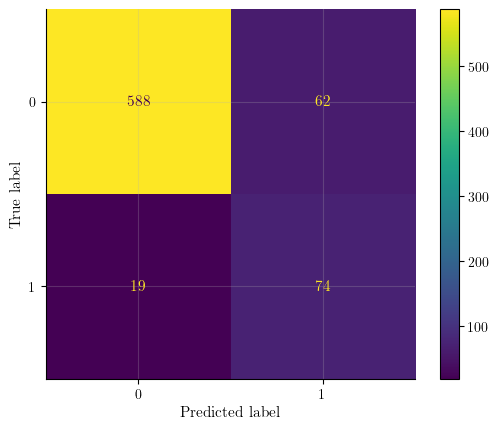

In [77]:
matrix = confusion_matrix(df["recession"].values, (states == 4).astype(int)+(states==2).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=matrix)
disp.plot()

accuracy = (matrix[0,0] + matrix[1,1]) / np.sum(matrix)
precision = matrix[0,0] / (matrix[0,0] + matrix[1,0])
recall = matrix[0,0] / (matrix[0,0] + matrix[0,1])
specificity = matrix[1,1] / (matrix[1,1] + matrix[1,0])
f1_score = 2 * (precision * recall) / (precision + recall)


tn, fp, fn, tp = matrix.ravel()
accuracy = (tp + tn) / matrix.sum()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * precision * recall / (precision + recall)
balanced_accuracy = (recall + specificity) / 2

print("=" * 35)
print(f"{'Evaluation Metric':<20} | {'Value':<10}")
print("=" * 35)
print(f"{'Accuracy':<20} | {accuracy:.4f}")
print(f"{'Precision':<20} | {precision:.4f}")
print(f"{'Recall':<20} | {recall:.4f}")
print(f"{'Specificity':<20} | {specificity:.4f}")
print(f"{'F1-Score':<20} | {f1:.4f}")
print(f"{'Balanced Accuracy':<20} | {balanced_accuracy:.4f}")
print("=" * 35)


Recall is now a lot better, this score increased from ~41% to ~80%. The rest of the metrics (bar f1 and balanced acc) have decreased slightly. However, the f1-score and balanced accuracy increases. I am not sure if this is useful or not, but I just thought that states 2/4 looked like they were very much sharing the recession points.

In [ ]:
recession_probability = best_model_k.predict_proba(Psi)[:, 4]
nber = df["recession"].to_numpy()

results = []

for offset in range(-6, 7):

    if offset > 0:
        probability_aligned = recession_probability[:-offset]
        nber_aligned = nber[offset:]
    elif offset < 0:
        probability_aligned = recession_probability[-offset:]
        nber_aligned = nber[:offset]
    else:
        probability_aligned = recession_probability
        nber_aligned = nber

    correlation = np.corrcoef(probability_aligned, nber_aligned)[0, 1]
    results.append({"offset": offset, "correlation": correlation})

lead_lag_df = pd.DataFrame(results)
lead_lag_df

,offset,correlation
0,-6,0.083160
1,-5,0.083190
2,-4,0.083219
3,-3,0.083249
4,-2,0.083278
5,-1,0.138895
6,0,0.138919
7,1,0.138895
8,2,0.083278
9,3,0.083249


The correlation for the zero lag is the highest of all. I think this is good, provided that the cohen's $\kappa$ score and f1-score is high enough anyway. It may have been nice to see a higher correlation and a short lag, which could then increase the afformentioned scores. This could be justified as a slight difference in the NBER definition of a recession.

#### (ii) Density coherence
We plot the density potential against time, while shading in the NBER recession dates. For the points with a high density potential ('high' is to be specified), but not classified as a recession point, we want to interpret.

To find what is meant by 'high potential', we look at the values of the potential which are classified as recession points. We can find the median density potential of these points, we then classify the points with a potential above this level as unexplained outliers.

In [ ]:
recession_mask = df["recession"].values.astype(bool)
recession_potential = V[recession_mask]
potential_threshold = np.median(recession_potential)

For the points where the potential is above a certain level, choose the maximum level in the surrounding 4 months so we don't have to interpret the 125 dates which are above this threshold.

In [157]:
# lots of the peaks ended up being points right next to recessions which weren't interesting. Now I pad the recessions
pad_months = 4
recession_padded = (pd.Series(recession_mask, index=df.index).rolling(window=2 * pad_months + 1, center=True, min_periods=1).max().astype(bool).to_numpy())

non_recession_series = np.where(~recession_padded, V, -np.inf)
peak_indices, peak_properties = find_peaks(non_recession_series, height=potential_threshold, distance=9, prominence=0.05)
low_density_episodes = pd.DataFrame({"date": df.index[peak_indices], "potential": V[peak_indices],
                                     "state": states[peak_indices], "peak_index": peak_indices}).sort_values("potential", ascending=False)

print(f'Number of unexplained high-potential points: {low_density_episodes.shape[0]}')
low_density_episodes.head(14)

Number of unexplained high-potential points: 21


,date,potential,state,peak_index
14,2010-05-01,3.097298,0,551
18,2022-09-01,2.248320,3,699
10,1990-01-01,2.139782,5,307
12,2002-07-01,2.014346,0,457
20,2026-03-01,1.969146,5,741
6,1984-08-01,1.922873,1,242
17,2019-05-01,1.911791,5,659
7,1986-02-01,1.901213,5,260
4,1981-02-01,1.872876,4,200
9,1987-11-01,1.822150,5,281


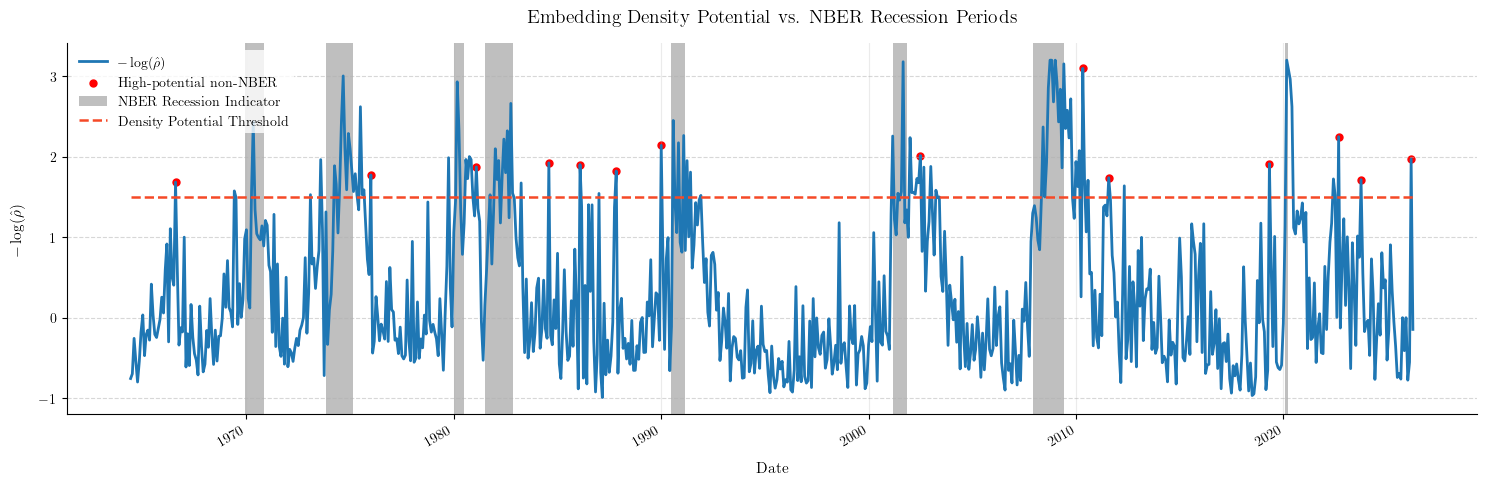

In [156]:
states = models[chosen_K].predict(Psi)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, V, label=r"$-\log(\hat\rho)$", color="#1f77b4", linewidth=2)

low_density_indices = low_density_episodes["peak_index"][:14]
ax.scatter(df.index[low_density_indices], V[low_density_indices], label="High-potential non-NBER", c="r")
y_min, y_max = ax.get_ylim()

ax.fill_between(df.index, y_min, y_max, where=(df["recession"].values == 1), color="gray",
                alpha=0.5, label="NBER Recession Indicator", edgecolor="none")

ax.hlines(potential_threshold, xmin=df.index[0], xmax=df.index[-1], linestyles="--", label="Density Potential Threshold", colors="#F54927")

ax.set_ylim(y_min, y_max)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

ax.set_title("Embedding Density Potential vs. NBER Recession Periods", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, labelpad=10)
ax.set_ylabel(r"$-\log(\hat\rho)$", fontsize=11, labelpad=10)

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False) 
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()
plt.show()


### Economic Outlier Analysis Table

| Date | Economic Outlier? | Brief Explanation |
| :--- | :---: | :--- |
| **1966-08-01** | **Yes** <br>*(Financial / Liquidity)* | **The Credit Crunch of 1966:** Extreme Fed tightening to cool a wartime investment boom led to a severe credit freeze in late August. Commercial banking liquidity ground to a near-halt, triggering a "mini-recession" in 1967 without an official NBER designation. |
| **1976-01-01** | **Yes** <br>*(Positive Boom / Data Break)* | **Post-Stagflation Rebound & BLS Structural Break:** Real GDP exploded by an extraordinary **9.2% annualized rate** in Q1 1976. Furthermore, January 1976 marks the exact launch of the BLS modern state-level unemployment database, creating a permanent statistical structural break in macro datasets. |
| **1981-02-01** | **Yes** <br>*(Monetary Policy)* | **Peak Volcker Shock:** Positioned directly between the double-dip recessions of the 1980s. Fed Chair Paul Volcker pushed the Federal Funds Rate to its absolute historical peak of **19-20%** to break hyperinflation, causing extreme anomalies in yield curves months before the July 1981 recession hit. |
| **1984-08-01** | **Yes** <br>*(Growth Slowdown)* | **Textbook "Soft Landing" Pivot:** The Fed Funds rate peaked at 11.6% as US economic growth abruptly decelerated from blistering 7–10% GDP gains in early 1984 down to 3.9% in Q3. This macro slowdown coincided with the massive, systemic rescue of Continental Illinois National Bank. |
| **1986-02-01** | **Yes** <br>*(Commodity Deflation)* | **The Great Oil Price Collapse of 1986:** Saudi Arabia flooded the market to reclaim market share, causing crude oil prices to plunge from ~$30/barrel to nearly $10/barrel by February. This shattered the US energy/industrial sector while acting as an aggressive positive shock for consumers. |
| **1987-11-01** | **Yes** <br>*(Financial Volatility)* | **Black Monday Aftermath:** The month immediately following the October 19, 1987 stock market crash. While the real economy avoided a recession, financial market data was highly anomalous, featuring historic spikes in equity volatility, wider credit risk spreads, and massive emergency Fed liquidity injections. |
| **1990-01-01** | **Partial** <br>*(Leading Signal)* | **Pre-Recession Macro Slowdown:** The official NBER recession didn't start until July 1990, making this a borderline false positive for coincident data. However, leading indicators in January 1990 were highly anomalous, featuring a deeply inverted yield curve, falling corporate profits, and stalling industrial output. |
| **2002-07-01** | **Yes** <br>*(Corporate & Market)* | **Corporate Accounting Crisis:** On July 21, 2002, WorldCom filed for the largest bankruptcy in US history at the time (hot on the heels of Enron). This induced severe panic, dragging global equity markets down to multi-year lows during a fragile, post-2001 "jobless recovery" phase. |
| **2010-05-01** | **Yes** <br>*(Financial Liquidity)* | **Eurozone Crisis & The Flash Crash:** On May 2, 2010, the IMF/Eurozone approved a €110 billion bailout for Greece, triggering global contagion fears. Days later, on May 6, the infamous "Flash Crash" wiped out nearly 1,000 points from the Dow in minutes, causing a massive, violent spike in systemic risk metrics. |
| **2011-08-01** | **Yes** <br>*(Sovereign Rating)* | **US Debt Credit Rating Downgrade:** Following a chaotic political standoff over the debt ceiling, Standard & Poor's **downgraded the United States' AAA credit rating** to AA+ for the first time in history on August 5, 2011. This sparked an extreme global equity liquidation and a collapse in consumer confidence. |
| **2019-05-01** | **Yes** <br>*(Trade Policy)* | **US-China Trade War Escalation:** On May 5, 2019, the Trump administration unexpectedly announced that tariffs on $200 billion of Chinese goods would hike from 10% to 25%. This policy shock disrupted global supply chains, deeply inverted the yield curve, and caused severe market corrections. |
| **2022-09-01** | **Yes** <br>*(Global Fixed Income)* | **Aggressive Tightening & The UK Pension Crisis:** The Fed executed consecutive historic 75 bps rate hikes to fight multi-decade inflation. Simultaneously, in late September, the UK "Mini-Budget" triggered a catastrophic LDI pension fund crisis, fracturing global bond stability and spiking fixed-income volatility. |
| **2023-10-01** | **Yes** <br>*(Fixed Income / Geopolitical)* | **The 5.0% 10-Year Yield Spike:** Long-term US Treasury yields surged rapidly, with the 10-year yield hitting 5.0% for the first time since 2007, heavily tightening global credit. Geopolitically, the October 7 conflict outbreak in Israel created an immediate risk premium shift across energy and safe-haven markets. |
| **2026-03-01** | **Yes** <br>*(Geopolitical Energy)* | **Middle East Energy Shock:** A severe escalation of conflict in the Middle East led to disruptions in the Strait of Hormuz, causing crude oil prices to surge by over 40% (WTI topping $100). Global equities fell sharply (S&P 500 down 5%, Nikkei down 13%), prompting central banks to halt planned rate cuts. |

---

### Investigation References & Deep-Dive Links

*   **1966 Credit Crunch:** Read the Federal Reserve Bank of Richmond's comprehensive historical analysis on [Identifying Credit Crunches](https://www.richmondfed.org/-/media/richmondfedorg/publications/research/working_papers/1993/pdf/wp93-2.pdf) to see how non-price rationing metrics peaked outside of a recession.
*   **1976 BLS Database Launch:** The International Monetary Fund details the structural timeline of modern US labor statistics in their working paper on [Postwar Recoveries Across U.S. States](https://www.imf.org/-/media/files/publications/wp/2022/english/wpiea2022117-print-pdf.pdf).
*   **1981 Monetary Policy Zenith:** Review the Federal Reserve's historical interest rate records via [FRED (Federal Reserve Economic Data)](https://fred.stlouisfed.org/series/FEDFUNDS) to verify the 19.1% effective federal funds rate peak in early 1981.
*   **1984 Soft Landing & Continental Illinois:** The Federal Reserve Bank of Minneapolis preserves the contemporary economic sentiment of this growth slowdown in their [August 1984 Beige Book Archive](https://www.minneapolisfed.org/beige-book-reports/1984/1984-08-su).
*   **1986 Oil Price Collapse:** The Federal Reserve Bank of St. Louis provides a historical retrospective on the macroeconomic impacts of the [1986 Crude Oil Shock](https://www.stlouisfed.org).
*   **1987 Black Monday Volatility:** Federal Reserve Board history outlines the emergency liquidity maneuvers implemented during November 1987 in the [Federal Reserve History Archive](https://www.federalreservehistory.org).
*   **1990 Pre-Recession Slowdown:** The Federal Reserve Bank of Boston breaks down the leading indicators and unique friction points leading up to the crash in [The 1990-91 Recession in Historical Perspective](https://www.bostonfed.org/-/media/Documents/neer/neer192a.pdf).
*   **2002 Corporate Accounting Scandals:** The Brookings Institution reviews the market disruptions caused by the historic bankruptcies of 2002 in their [Retrospective on American Economic Policy](https://www.brookings.edu/articles/retrospective-on-american-economic-policy-in-the-1990s/).
*   **2010 Eurozone Bailouts & Flash Crash:** Review the systemic volatility data and timelines via the [U.S. Securities and Exchange Commission (SEC) Flash Crash Joint Report](https://www.sec.gov).
*   **2011 Debt Downgrade:** Refer to the [Council on Foreign Relations (CFR)](https://www.cfr.org) analysis on the global economic ripples caused by the historic S&P sovereign downgrade.
*   **2019 Tariff Policy Shock:** The [Peterson Institute for International Economics (PIIE)](https://www.piie.com) provides a step-by-step timeline of the May 2019 tariff hikes and their measurable impact on supply chain metrics.
*   **2022 Monetary Tightening & LDI Crisis:** Read the [Bank for International Settlements (BIS)](https://www.bis.org) quarterly review detailing how global fixed-income volatility peaked during the September 2022 monetary policy convergence.
*   **2023 Long-Term Yield Rout:** Track the 10-year Treasury yield spikes via the [FRED 10-Year Treasury Constant Maturity Series](https://fred.stlouisfed.org/series/GS10).
*   **2026 Middle East Energy Crisis:** See the comprehensive macroeconomic impacts of the 2026 energy supply shock outlined in the [Janus Henderson Global Market Review](https://www.janushenderson.com).